# Exploring ViZDoom's Hidden Internal State (GameState, Labels, Objects)
While the `fmri-gym` setup only saves the essential `gamevariables` (like Health) to the `.npz` file, the underlying ViZDoom engine is tracking a massive amount of rich 3D state data.

By utilizing the **Seed + Action Replay** mechanism we validated earlier, we can cleanly reconstruct the game session and explicitly instruct the ViZDoom C++ engine to hand over semantic segmentation (`labels_buffer`), depth maps, and exact 3D coordinates for all entities (`objects`).


In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import vizdoom.gymnasium_wrapper

# We'll use the Deadly Corridor recording (which has enemies) to see the labels!
DATASET_DIR = os.path.abspath("../data/sub-01_20260909-135403")

# Load configuration and actions
manifest_path = os.path.join(DATASET_DIR, "manifest.json")
with open(manifest_path, "r") as f:
    manifest = json.load(f)

game_curriculum = next(p for p in manifest["curriculum"] if p.get("type") == "game")
game_phase = next(p for p in manifest["phases"] if p.get("type") == "game")
data = np.load(os.path.join(DATASET_DIR, game_phase["data_file"]), allow_pickle=True)

env_kwargs = game_curriculum.get("env_kwargs", {})
game_name = game_curriculum["game"]
actions = data["actions"]
seed = int(data["episode_seeds"][0])

print(f"Loaded {game_name}. Ready to replay seed {seed}!")



Loaded VizdoomDeadlyCorridor-v1. Ready to replay seed 1002!


## Instantiating the Engine and Enabling Extended Buffers
We create the Gymnasium environment as usual, but before we run it, we reach inside the wrapper to talk directly to the underlying `DoomGame` C++ object. We tell it to enable the semantic label buffer and object tracking.


In [2]:
env = gym.make(game_name, render_mode="rgb_array", **env_kwargs)
game = env.unwrapped.game

# To change buffer settings, we must close the current engine instance, 
# enable the new buffers, and re-initialize it.
game.close()
game.set_labels_buffer_enabled(True)
game.set_objects_info_enabled(True)
game.set_sectors_info_enabled(True)
game.set_depth_buffer_enabled(True)
game.init()

# Reset the gym wrapper (this correctly sets the seed and prepares the first frame)
obs, info = env.reset(seed=seed)



## Replaying to an Action-Packed Frame
Let's step forward into the game (e.g., 40 frames in) where enemies are visible, then extract the complete `GameState`.


In [ ]:

for t in range(40): # Fast-forward 40 frames into the episode
    env.step(actions[t])
state = game.get_state() # Retrieve ViZDoom GameState

print("GameState retrieved!")
print(f"Current Tic (Ingame time): {state.tic}")
print(f"Number of Objects Tracked: {len(state.objects)}")
print(f"Number of Labels in Mask : {len(state.labels)}")



GameState retrieved!
Current Tic (Ingame time): 41
Number of Objects Tracked: 8
Number of Labels in Mask : 4


## Visualizing the Hidden Buffers
Now we will extract the standard RGB Screen Buffer, the Depth Buffer, and the Semantic Labels Buffer (which assigns a unique ID to every object class in the map).


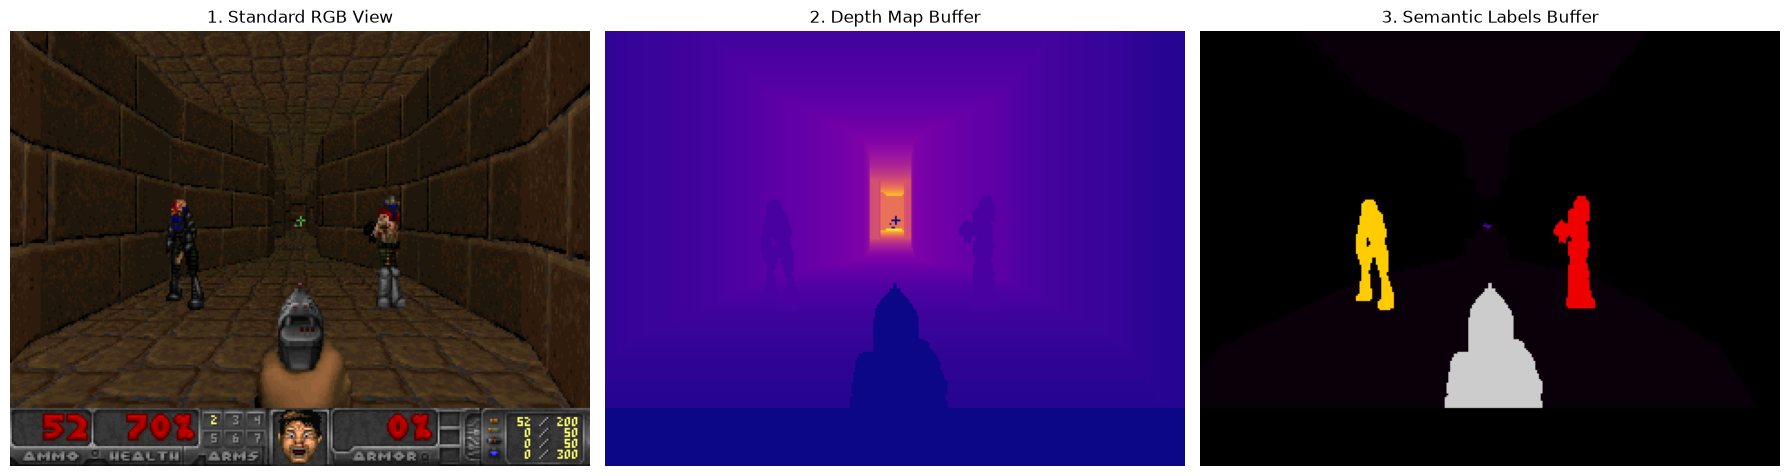

In [4]:
screen = state.screen_buffer
depth = state.depth_buffer
labels_map = state.labels_buffer

# ViZDoom natively returns buffers in (Channels, Height, Width) format, so we transpose them for Matplotlib
if screen.shape[0] == 3:
    screen = np.transpose(screen, (1, 2, 0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(screen)
axes[0].set_title("1. Standard RGB View")
axes[0].axis('off')

axes[1].imshow(depth, cmap="plasma")
axes[1].set_title("2. Depth Map Buffer")
axes[1].axis('off')

axes[2].imshow(labels_map, cmap="nipy_spectral")
axes[2].set_title("3. Semantic Labels Buffer")
axes[2].axis('off')

plt.tight_layout()
plt.show()



## Inspecting the `Object` and `Label` Properties
ViZDoom isn't just generating pixels—it provides the exact properties of the entities in the world.


In [5]:
import pandas as pd

print("=== ENTITIES IN THE WORLD SCENE (Top 10) ===")
object_data = []
for obj in state.objects[:10]:
    object_data.append({
        "Name": obj.name,
        "ID": obj.id,
        "X": round(obj.position_x, 2),
        "Y": round(obj.position_y, 2),
        "Z": round(obj.position_z, 2),
        "Velocity (X,Y)": f"({round(obj.velocity_x, 1)}, {round(obj.velocity_y, 1)})"
    })

display(pd.DataFrame(object_data))


print("\n=== VISIBLE LABELS ON SCREEN ===")
label_data = []
for label in state.labels:
    # Filter out the floor/ceiling background labels if desired, or just show them
    label_data.append({
        "Object Name": label.object_name,
        "Category": label.object_category,
        "Bounding Box": f"x={label.x}, y={label.y}, w={label.width}, h={label.height}",
        "Buffer Value": label.value
    })

display(pd.DataFrame(label_data))



=== ENTITIES IN THE WORLD SCENE (Top 10) ===


,Name,ID,X,Y,Z,"Velocity (X,Y)"
0,DoomPlayer,3,-15.93,-8.22,0.0,"(0.0, 0.0)"
1,GreenArmor,0,1312.00,0.00,0.0,"(0.0, 0.0)"
2,ChaingunGuy,4,1024.00,64.00,0.0,"(0.0, 0.0)"
3,Zombieman,5,608.00,64.00,0.0,"(0.0, 0.0)"
4,ShotgunGuy,2,160.00,64.00,0.0,"(0.0, 0.0)"
5,ShotgunGuy,6,1024.00,-64.00,0.0,"(0.0, 0.0)"
6,ChaingunGuy,7,608.00,-64.00,0.0,"(0.0, 0.0)"
7,Zombieman,1,160.00,-64.00,0.0,"(0.0, 0.0)"



=== VISIBLE LABELS ON SCREEN ===


,Object Name,Category,Bounding Box,Buffer Value
0,GreenArmor,Armor,"x=156, y=106, w=4, h=2",31
1,Zombieman,Monster,"x=195, y=91, w=22, h=61",223
2,ShotgunGuy,Monster,"x=86, y=93, w=20, h=60",191
3,DoomPlayer,Self,"x=135, y=139, w=53, h=68",255


In [ ]:
env.close()
